# Notebook thử nghiệm toàn bộ pineline:

In [20]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

BOOTSTRAP_ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(BOOTSTRAP_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOTSTRAP_ROOT))

from src.evaluation.accuracy import accuracy
from src.evaluation.confusion_matrix import confusion_matrix
from src.feature_extraction.count_vectorizer import CountVectorizer
from src.models.decision_tree.decision_tree import DecisionTree
from src.models.naive_bayes.naive_bayes import NaiveBayes
from src.preprocessing.text_processor import TextProcessor
from src.utils.helper import train_test_split
from src.utils.notebook_setup import (
    find_csv_file,
    load_sentiment_dataset,
    resolve_project_root,
    summarize_dataset,
)

PROJECT_ROOT = resolve_project_root()
DATA_ROOT = PROJECT_ROOT / 'data' / 'raw'

plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 140)

imdb_path = find_csv_file(DATA_ROOT / 'imdb')
sst_path = DATA_ROOT / 'sst' / 'train.csv'

imdb_bundle = load_sentiment_dataset(imdb_path, 'IMDB')
sst_bundle = load_sentiment_dataset(sst_path, 'SST')

imdb_summary, imdb_label_counts, imdb_lengths = summarize_dataset(imdb_bundle)
sst_summary, sst_label_counts, sst_lengths = summarize_dataset(sst_bundle)

summary_table = pd.concat([imdb_summary, sst_summary], ignore_index=True)
summary_table

,dataset,rows,unique_labels,avg_tokens,median_tokens,min_tokens,max_tokens
0,IMDB,50000,2,231.156940,173.0,4,2470
1,SST,67349,2,9.409553,7.0,1,52


In [21]:
print('IMDB raw columns:', list(imdb_bundle['raw'].columns))
print('SST raw columns:', list(sst_bundle['raw'].columns))

print('\nIMDB preview:')
display(imdb_bundle['raw'].head(3))

print('\nSST preview:')
display(sst_bundle['raw'].head(3))

print('\nLabel counts:')
display(imdb_label_counts.rename_axis('label').reset_index(name='count'))
display(sst_label_counts.rename_axis('label').reset_index(name='count'))

print('\nSummary table:')
display(summary_table)

IMDB raw columns: ['review', 'sentiment']
SST raw columns: ['id', 'target', 'sentence']

IMDB preview:


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as ...",positive
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and g...,positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater...",positive



SST preview:


,id,target,sentence
0,16399,0,b'for the uninitiated plays better on video with the sound '
1,1680,0,"b'like a giant commercial for universal studios , where much of the action takes place '"
2,47917,1,b'company once again dazzle and delight us '



Label counts:


,label,count
0,negative,25000
1,positive,25000


,label,count
0,0,29780
1,1,37569



Summary table:


,dataset,rows,unique_labels,avg_tokens,median_tokens,min_tokens,max_tokens
0,IMDB,50000,2,231.156940,173.0,4,2470
1,SST,67349,2,9.409553,7.0,1,52


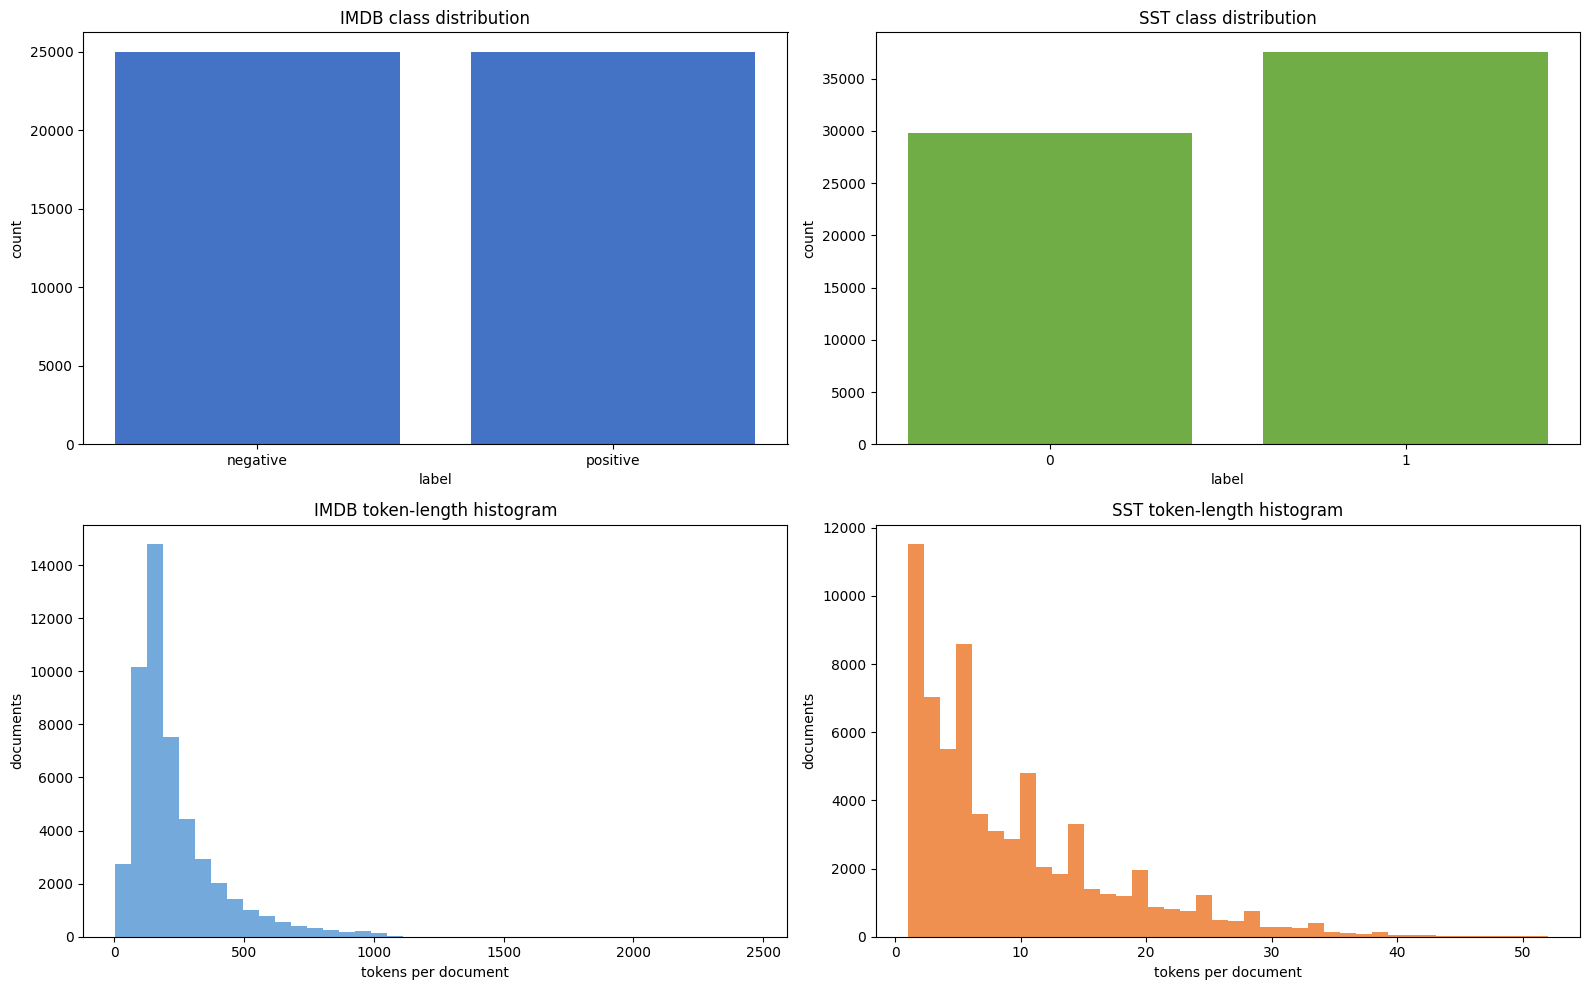

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].bar(imdb_label_counts.index.astype(str), imdb_label_counts.values, color='#4472c4')
axes[0, 0].set_title('IMDB class distribution')
axes[0, 0].set_xlabel('label')
axes[0, 0].set_ylabel('count')

axes[0, 1].bar(sst_label_counts.index.astype(str), sst_label_counts.values, color='#70ad47')
axes[0, 1].set_title('SST class distribution')
axes[0, 1].set_xlabel('label')
axes[0, 1].set_ylabel('count')

axes[1, 0].hist(imdb_lengths, bins=40, color='#5b9bd5', alpha=0.85)
axes[1, 0].set_title('IMDB token-length histogram')
axes[1, 0].set_xlabel('tokens per document')
axes[1, 0].set_ylabel('documents')

axes[1, 1].hist(sst_lengths, bins=40, color='#ed7d31', alpha=0.85)
axes[1, 1].set_title('SST token-length histogram')
axes[1, 1].set_xlabel('tokens per document')
axes[1, 1].set_ylabel('documents')

plt.tight_layout()

,raw_text,cleaned_text,tokens,token_count
0,"I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting ...",i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting t...,really liked summerslam due look arena curtains just look overall was interesting me some reason anyways one best su...,137
1,Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and...,not many television shows appeal to quite as many different kinds of fans like farscape does i know youngsters and y...,not many television shows appeal quite as many different kinds fans like farscape know youngsters years old fans bot...,224
2,The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy...,the film quickly gets to a major chase scene with ever increasing destruction the first really bad thing is the guy ...,film quickly gets major chase scene ever increasing destruction first really bad thing guy hijacking steven seagal b...,70
3,"is , truly and thankfully , a one-of-a-kind work",is truly and thankfully a one of a kind work,truly thankfully one kind work,5
4,the clumsy cliché,the clumsy cliché,clumsy cliché,2
5,fuddled,fuddled,fuddled,1


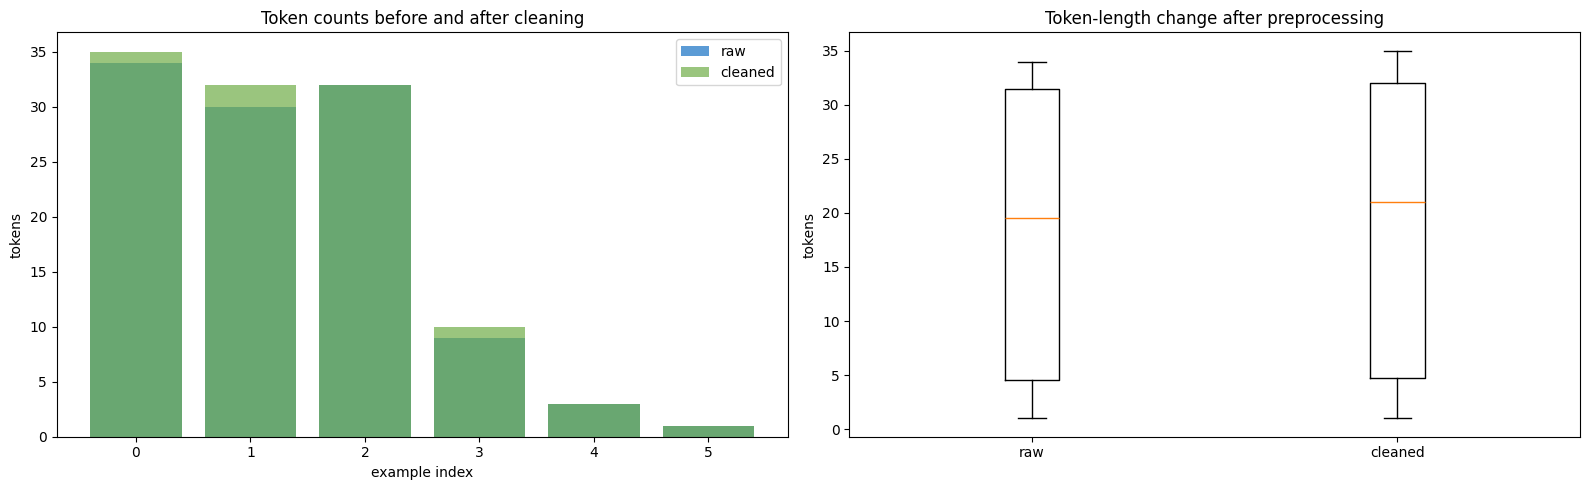

In [23]:
processor = TextProcessor(remove_stopwords=True, remove_numbers=True)
preprocess_samples = (
    imdb_bundle['data']['text'].dropna().sample(3, random_state=42).tolist()
    + sst_bundle['data']['text'].dropna().sample(3, random_state=42).tolist()
 )

preprocess_rows = []
for sample in preprocess_samples:
    cleaned = processor.clean(sample)
    tokens = processor.process(sample)
    preprocess_rows.append({
        'raw_text': sample[:180],
        'cleaned_text': cleaned[:180],
        'tokens': ' '.join(tokens[:25]),
        'token_count': len(tokens),
    })

preprocess_demo = pd.DataFrame(preprocess_rows)
display(preprocess_demo)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
length_frame = preprocess_demo.copy()
length_frame['raw_len'] = length_frame['raw_text'].map(lambda text: len(str(text).split()))
length_frame['clean_len'] = length_frame['cleaned_text'].map(lambda text: len(str(text).split()))

axes[0].bar(range(len(length_frame)), length_frame['raw_len'], color='#5b9bd5', label='raw')
axes[0].bar(range(len(length_frame)), length_frame['clean_len'], color='#70ad47', alpha=0.7, label='cleaned')
axes[0].set_title('Token counts before and after cleaning')
axes[0].set_xlabel('example index')
axes[0].set_ylabel('tokens')
axes[0].legend()

axes[1].boxplot([length_frame['raw_len'], length_frame['clean_len']], tick_labels=['raw', 'cleaned'])
axes[1].set_title('Token-length change after preprocessing')
axes[1].set_ylabel('tokens')

plt.tight_layout()

In [24]:
limit = 1200
feature_sample = imdb_bundle['data'].dropna(subset=['text', 'label']).sample(min(limit, len(imdb_bundle['data'])), random_state=42).copy()
feature_sample['processed_text'] = feature_sample['text'].map(lambda text: ' '.join(processor.process(text)))

label_codes, label_uniques = pd.factorize(feature_sample['label'])
label_to_name = {idx: str(name) for idx, name in enumerate(label_uniques)}

feature_train_text, feature_test_text, feature_train_y, feature_test_y = train_test_split(
    np.array(feature_sample['processed_text'].tolist()),
    np.array(label_codes.astype(int)),
    test_size=0.2,
    random_state=42,
    stratify=True,
 )

vectorizer = CountVectorizer(lowercase=True, ngram_range=(1, 1), max_features=1500)
X_train_counts = vectorizer.fit_transform(feature_train_text)
X_test_counts = vectorizer.transform(feature_test_text)

vocab_size = len(vectorizer.vocabulary_)
train_sparsity = 1.0 - (X_train_counts.nnz / (X_train_counts.shape[0] * X_train_counts.shape[1]))
column_sums = np.asarray(X_train_counts.sum(axis=0)).ravel()
inv_vocab = {index: token for token, index in vectorizer.vocabulary_.items()}
top_term_indices = np.argsort(column_sums)[-15:][::-1]
top_terms = pd.DataFrame({
    'token': [inv_vocab[index] for index in top_term_indices],
    'count': column_sums[top_term_indices],
})

feature_summary = pd.DataFrame({
    'metric': ['vocab_size', 'train_rows', 'train_cols', 'nnz', 'sparsity'],
    'value': [vocab_size, X_train_counts.shape[0], X_train_counts.shape[1], X_train_counts.nnz, train_sparsity],
})

feature_bundle = {
    'train_text': feature_train_text,
    'test_text': feature_test_text,
    'train_y': feature_train_y,
    'test_y': feature_test_y,
    'label_to_name': label_to_name,
    'count_vectorizer': vectorizer,
    'X_train': X_train_counts,
    'X_test': X_test_counts,
}

display(feature_summary)
display(top_terms)

,metric,value
0,vocab_size,1500.000000
1,train_rows,959.000000
2,train_cols,1500.000000
3,nnz,73799.000000
4,sparsity,0.948697


,token,count
0,was,1883.0
1,as,1701.0
2,movie,1694.0
3,film,1600.0
4,not,1180.0
5,his,1109.0
6,one,1030.0
7,all,919.0
8,so,832.0
9,like,813.0


In [25]:
def build_report(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if np.issubdtype(y_pred.dtype, np.floating):
        y_pred = y_pred.astype(int)
    if np.issubdtype(y_true.dtype, np.floating):
        y_true = y_true.astype(int)

    cm, classes = confusion_matrix(y_true, y_pred)
    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0).astype(float) - tp
    fn = cm.sum(axis=1).astype(float) - tp

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) != 0)

    rows = []
    for idx, cls in enumerate(classes):
        rows.append({
            'label': str(int(cls)) if np.issubdtype(np.asarray([cls]).dtype, np.number) else str(cls),
            'precision': float(precision[idx]),
            'recall': float(recall[idx]),
            'f1': float(f1[idx]),
            'support': int(cm[idx].sum()),
        })

    rows.append({
        'label': 'macro_avg',
        'precision': float(precision.mean()),
        'recall': float(recall.mean()),
        'f1': float(f1.mean()),
        'support': int(len(y_true)),
    })

    report = pd.DataFrame(rows)
    return {
        'accuracy': float(accuracy(y_true, y_pred)),
        'confusion_matrix': cm,
        'classes': classes,
        'report': report,
    }


def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = np.asarray(model.predict(X_test))
    if np.issubdtype(predictions.dtype, np.floating):
        predictions = predictions.astype(int)
    metrics = build_report(y_test, predictions)
    return {
        'model': model_name,
        'predictions': predictions,
        'metrics': metrics,
    }

In [26]:
nb_results = evaluate_model(
    model_name='Naive Bayes',
    model=NaiveBayes(alpha=1.0),
    X_train=feature_bundle['X_train'],
    X_test=feature_bundle['X_test'],
    y_train=feature_bundle['train_y'],
    y_test=feature_bundle['test_y'],
)

display(nb_results['metrics']['report'].assign(model='Naive Bayes'))

,label,precision,recall,f1,support,model
0,0,0.825243,0.739130,0.779817,115,Naive Bayes
1,1,0.782609,0.857143,0.818182,126,Naive Bayes
2,macro_avg,0.803926,0.798137,0.798999,241,Naive Bayes


In [27]:
dt_results = evaluate_model(
    model_name='Decision Tree',
    model=DecisionTree(max_depth=8, min_samples_split=5),
    X_train=feature_bundle['X_train'],
    X_test=feature_bundle['X_test'],
    y_train=feature_bundle['train_y'],
    y_test=feature_bundle['test_y'],
)

dt_results['metrics']['report']

,label,precision,recall,f1,support
0,0,0.605442,0.773913,0.679389,115
1,1,0.723404,0.539683,0.618182,126
2,macro_avg,0.664423,0.656798,0.648786,241


In [28]:
results = [nb_results, dt_results]
results_df = pd.DataFrame([{
    'model': item['model'],
    'accuracy': item['metrics']['accuracy'],
    'precision_macro': item['metrics']['report'].iloc[-1]['precision'],
    'recall_macro': item['metrics']['report'].iloc[-1]['recall'],
    'f1_macro': item['metrics']['report'].iloc[-1]['f1'],
} for item in results]).sort_values('f1_macro', ascending=False).reset_index(drop=True)

display(results_df)
best_row = results_df.iloc[0]
print('Best model:', best_row['model'])

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Naive Bayes,0.800830,0.803926,0.798137,0.798999
1,Decision Tree,0.651452,0.664423,0.656798,0.648786


Best model: Naive Bayes


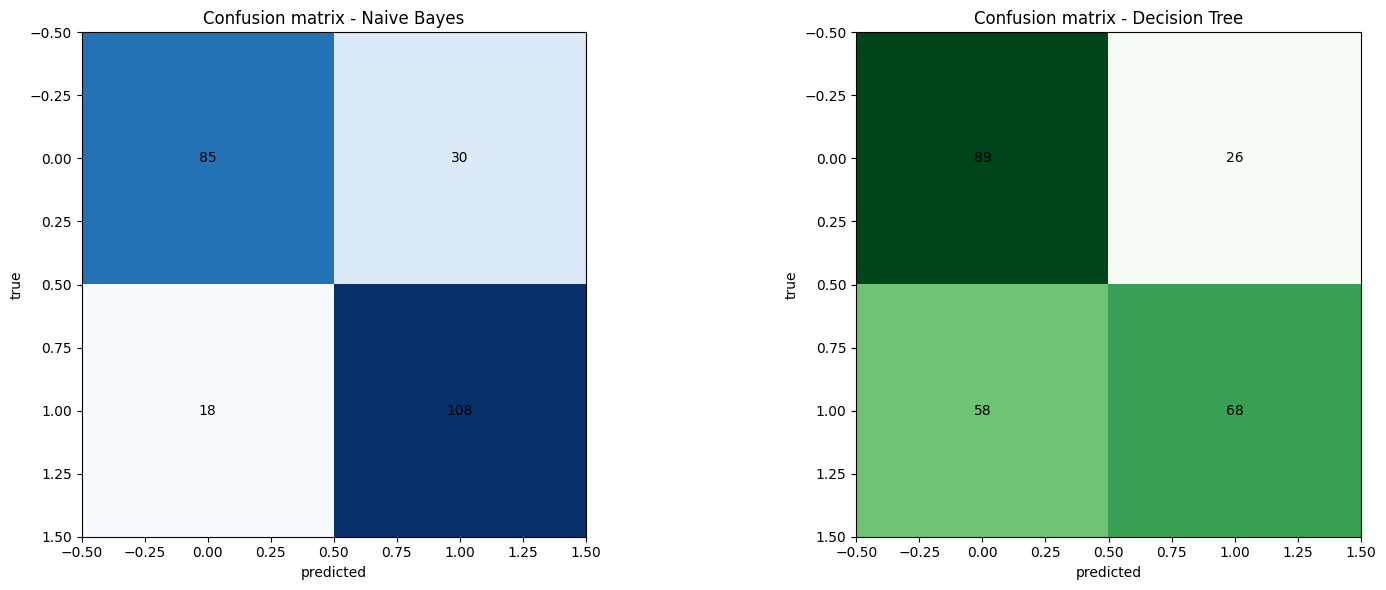

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(nb_results['metrics']['confusion_matrix'], cmap='Blues')
axes[0].set_title('Confusion matrix - Naive Bayes')
axes[0].set_xlabel('predicted')
axes[0].set_ylabel('true')
for i in range(nb_results['metrics']['confusion_matrix'].shape[0]):
    for j in range(nb_results['metrics']['confusion_matrix'].shape[1]):
        axes[0].text(j, i, int(nb_results['metrics']['confusion_matrix'][i, j]), ha='center', va='center')

axes[1].imshow(dt_results['metrics']['confusion_matrix'], cmap='Greens')
axes[1].set_title('Confusion matrix - Decision Tree')
axes[1].set_xlabel('predicted')
axes[1].set_ylabel('true')
for i in range(dt_results['metrics']['confusion_matrix'].shape[0]):
    for j in range(dt_results['metrics']['confusion_matrix'].shape[1]):
        axes[1].text(j, i, int(dt_results['metrics']['confusion_matrix'][i, j]), ha='center', va='center')

plt.tight_layout()

In [30]:
final_report = pd.concat([
    nb_results['metrics']['report'].assign(model='Naive Bayes'),
    dt_results['metrics']['report'].assign(model='Decision Tree'),
], ignore_index=True)

display(final_report)

best_result = nb_results if nb_results['metrics']['accuracy'] >= dt_results['metrics']['accuracy'] else dt_results
print('Final best model:', best_result['model'])
print('Final accuracy:', round(best_result['metrics']['accuracy'], 4))

,label,precision,recall,f1,support,model
0,0,0.825243,0.739130,0.779817,115,Naive Bayes
1,1,0.782609,0.857143,0.818182,126,Naive Bayes
2,macro_avg,0.803926,0.798137,0.798999,241,Naive Bayes
3,0,0.605442,0.773913,0.679389,115,Decision Tree
4,1,0.723404,0.539683,0.618182,126,Decision Tree
5,macro_avg,0.664423,0.656798,0.648786,241,Decision Tree


Final best model: Naive Bayes
Final accuracy: 0.8008
